In [ ]:
import matplotlib
import numpy as np
import matplotlib.pyplot as plt
import os
import glob as gb
import cv2
import tensorflow as tf
import keras
import pandas
import pandas as pd

2024-03-17 19:58:39.443591: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-03-17 19:58:39.443708: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-03-17 19:58:39.574835: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [ ]:
# pip install numpy

path of data set


In [ ]:
path = '/kaggle/input/normal-and-tumor2/ct/'

**size of training data**

In [ ]:
for folder in  os.listdir(path + 'seg_train') : 
    files = gb.glob(pathname= str( path +'seg_train//' + folder + '/*.jpg'))
    print(f'For training data , found {len(files)} in folder {folder}')

For training data , found 1015 in folder tumor
For training data , found 1500 in folder normal


size of testing data

In [ ]:
for folder in  os.listdir(path + 'seg_test') : 
    files = gb.glob(pathname= str( path +'seg_test//' + folder + '/*.jpg'))
    print(f'For testing data , found {len(files)} in folder {folder}')

For testing data , found 421 in folder tumor
For testing data , found 413 in folder normal


**size of pred data**

In [ ]:
for folder in  os.listdir(path + 'seg_pred') : 
    files = gb.glob(pathname= str( path +'seg_pred//' + folder + '/*.jpg'))
    print(f'For predication data , found {len(files)} in folder {folder}')

For predication data , found 72 in folder normal&tumor


In [ ]:
code = {'normal':0 ,'tumor':1}

def getcode(n) :
    for x , y in code.items() :
        if n == y :
            return x

In [ ]:
size = []
for folder in  os.listdir(path +'seg_train') : 
    files = gb.glob(pathname= str( path +'seg_train//' + folder + '/*.jpg'))
    for file in files: 
        image = plt.imread(file)
        size.append(image.shape)
pd.Series(size).value_counts()

(512, 512)    1629
(768, 768)     551
(224, 224)     158
(766, 766)      77
(512, 623)      52
(512, 801)      46
(404, 511)       1
(331, 506)       1
Name: count, dtype: int64

In [ ]:
size = []
for folder in  os.listdir(path +'seg_test') : 
    files = gb.glob(pathname= str( path +'seg_test//' + folder + '/*.jpg'))
    for file in files: 
        image = plt.imread(file)
        size.append(image.shape)
pd.Series(size).value_counts()

(512, 512)    477
(768, 768)    261
(766, 766)     36
(512, 623)     31
(512, 801)     28
(331, 506)      1
Name: count, dtype: int64

In [ ]:
size = []
for folder in  os.listdir(path +'seg_pred') : 
    files = gb.glob(pathname= str( path +'seg_pred//' + folder + '/*.jpg'))
    for file in files: 
        image = plt.imread(file)
        size.append(image.shape)
pd.Series(size).value_counts()

(512, 512)    72
Name: count, dtype: int64

In [ ]:
s=200
X_train = []
y_train = []


for folder in os.listdir(path + '/seg_train'):
    files = gb.glob(pathname=(path + 'seg_train//' + folder + '/*.jpg'))
    for file in files:
        image = cv2.imread(file)
        if image is not None:  # Check if the image was successfully loaded
            image = cv2.resize(image, (200, 200), interpolation=cv2.INTER_AREA)
            image = image / 255.0  # Normalize pixel values to the range [0, 1]

            X_train.append(list(image))
            y_train.append(code[folder])
        else:
            print(f"Failed to load image: {file}")
            
            
print(f'we have {len(X_train)} items in X_train')
print(f'we have {len(y_train)} items in X_train')

we have 2515 items in X_train
we have 2515 items in X_train


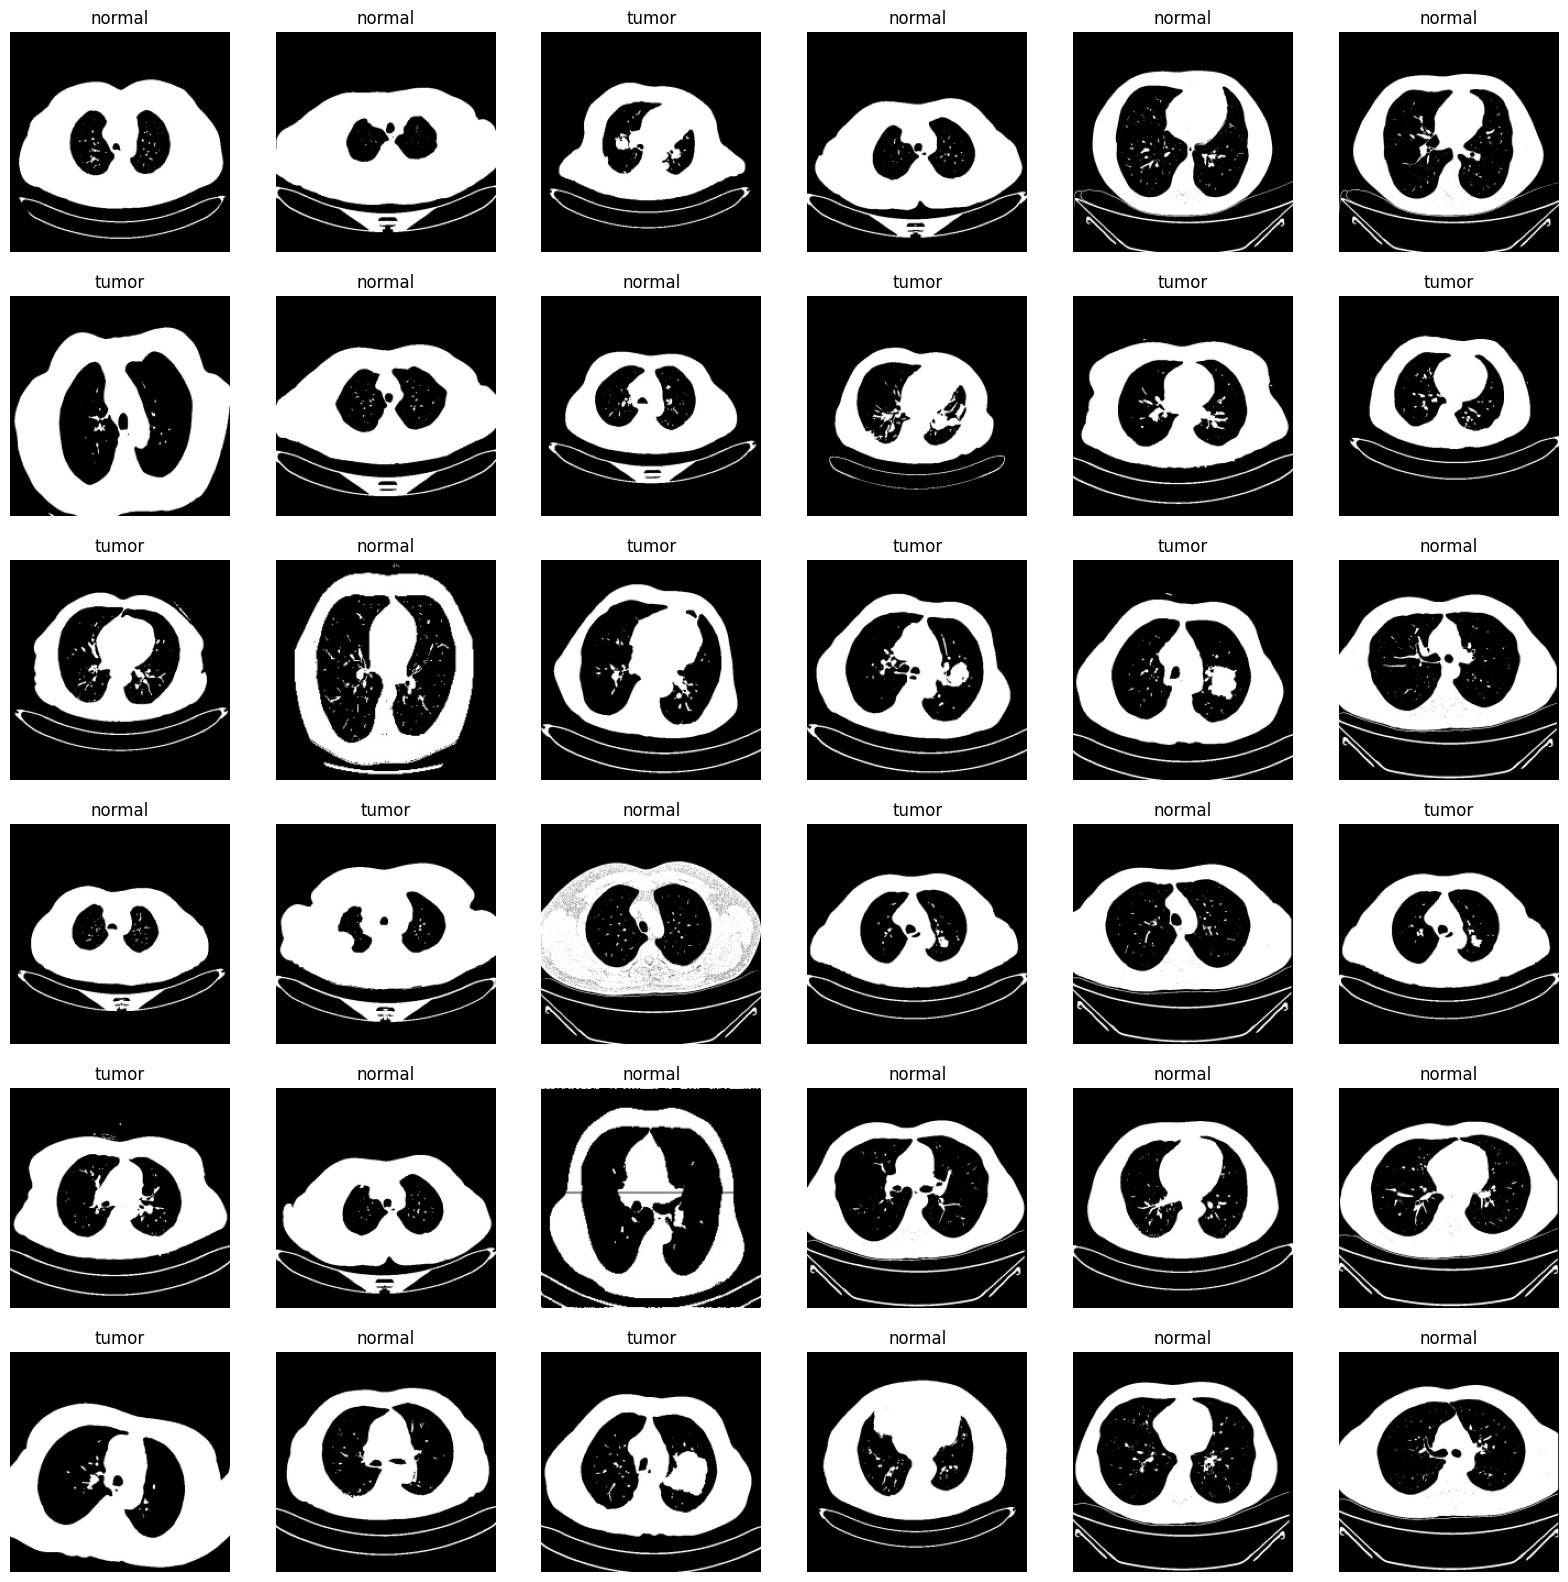

In [ ]:
plt.figure(figsize=(20,20))
for n , i in enumerate(list(np.random.randint(0,len(X_train),36))) : 
    plt.subplot(6,6,n+1)
    plt.imshow(X_train[i])   
    plt.axis('off')
    plt.title(getcode(y_train[i]))

In [ ]:
X_test = []
y_test = []
for folder in  os.listdir(path +'/seg_test') :
    files = gb.glob(pathname= str(path + 'seg_test//' + folder + '/*.jpg'))
    for file in files:
        image = cv2.imread(file)
        image_array = cv2.resize(image , (200,200))
        image_array = image_array / 255.0  # Normalize pixel values to the range [0, 1]
        X_test.append(list(image_array))
        y_test.append(code[folder])

print(f'we have {len(X_test)} items in X_test')


we have 834 items in X_test


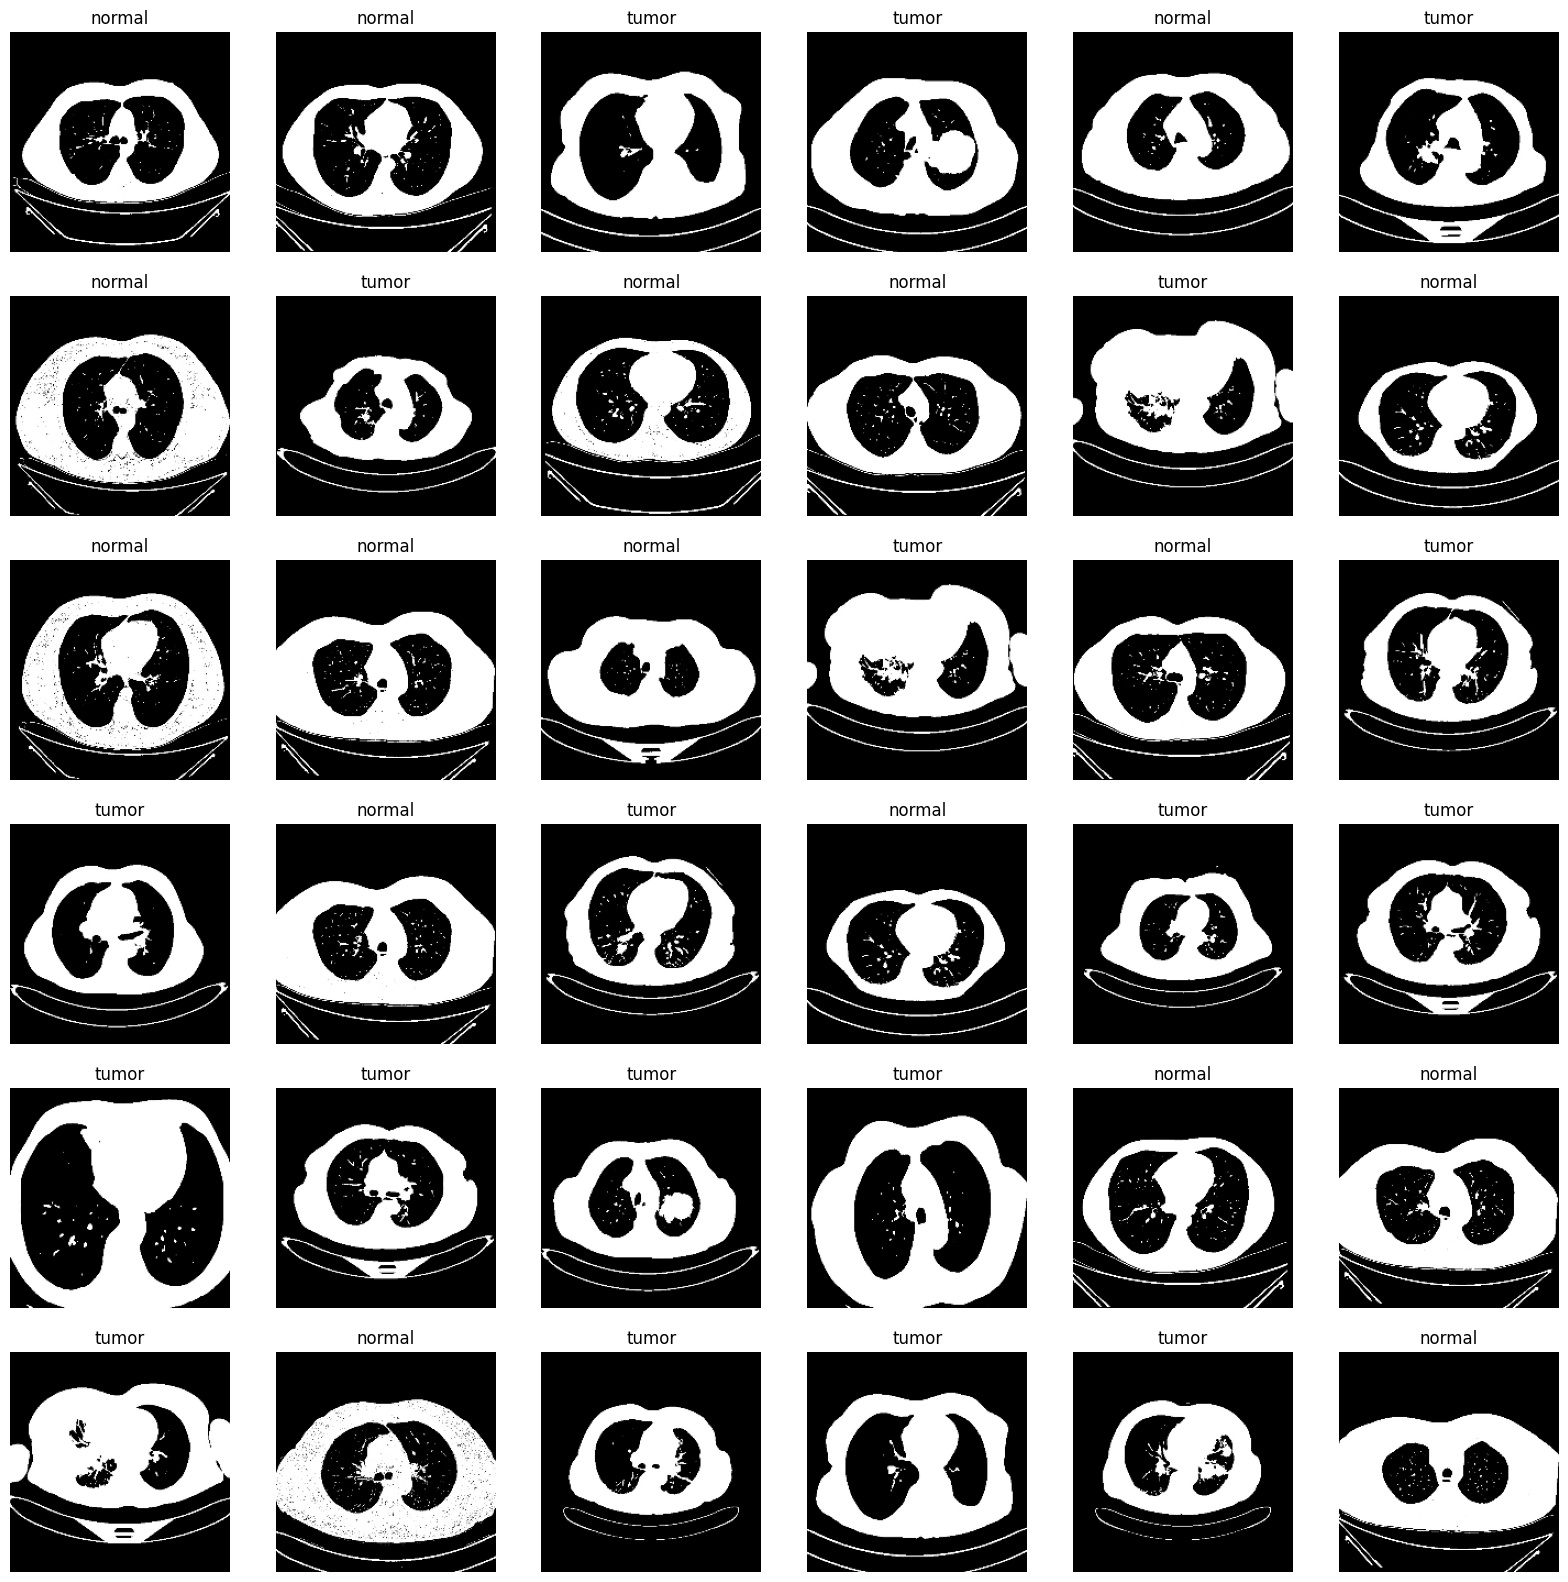

In [ ]:
plt.figure(figsize=(20,20))
for n , i in enumerate(list(np.random.randint(0,len(X_test),36))) : 
    plt.subplot(6,6,n+1)
    plt.imshow(X_test[i])   
    plt.axis('off')
    plt.title(getcode(y_test[i]))

In [ ]:
X_pred = []
for folder in  os.listdir(path +'/seg_pred') :
    files = gb.glob(pathname= str(path + 'seg_pred//' + folder + '/*.jpg'))
    for file in files:
        image = cv2.imread(file)
        image_array = cv2.resize(image , (200,200))
        image_array = image_array / 255.0  # Normalize pixel values to the range [0, 1]
        X_pred.append(list(image_array))
    
print(f'we have {len(X_pred)} items in X_pred')

we have 72 items in X_pred


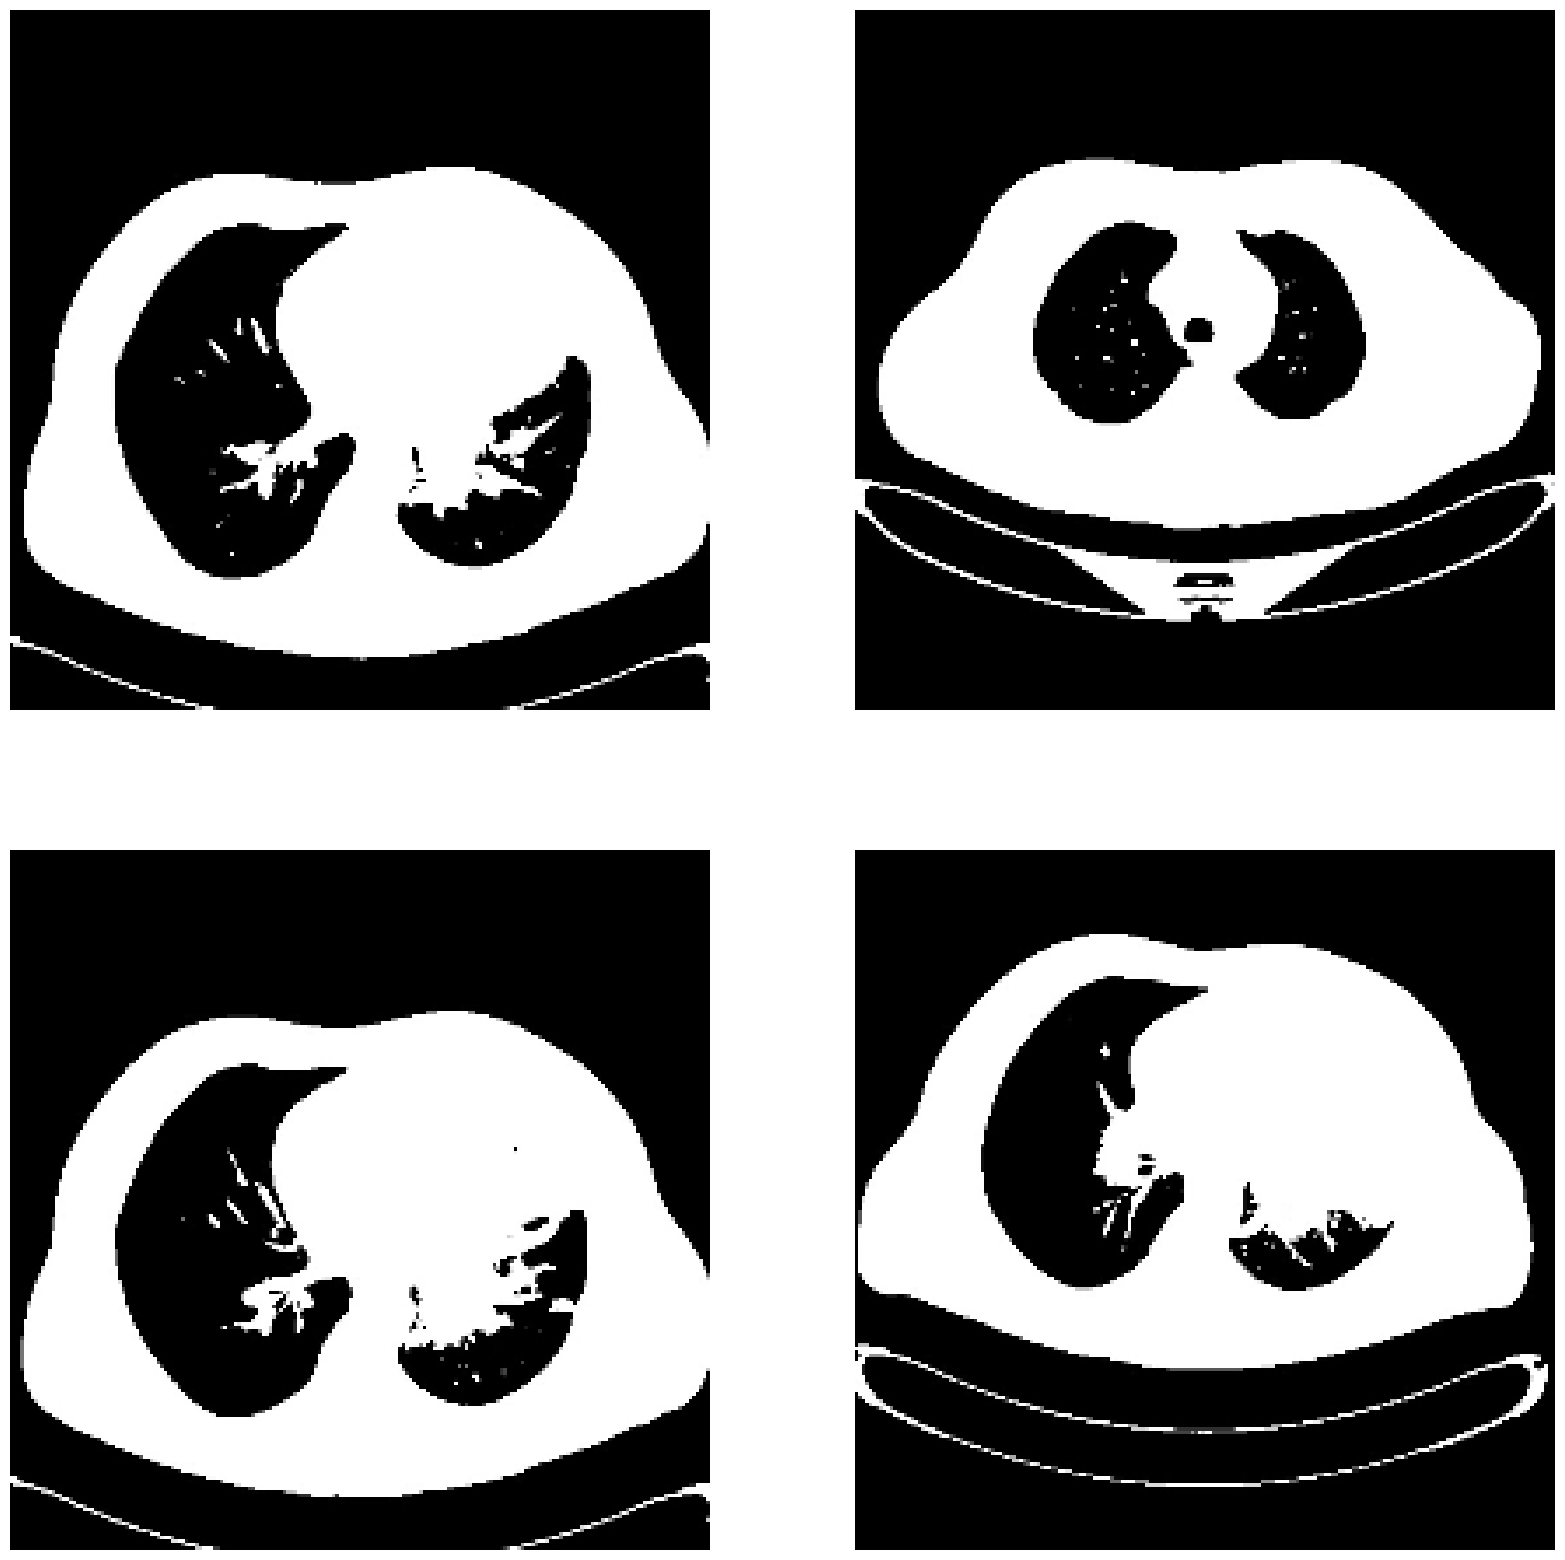

In [ ]:
plt.figure(figsize=(20,20))
for n , i in enumerate(list(np.random.randint(0,len(X_pred),4))) : 
    plt.subplot(2,2,n+1)
    plt.imshow(X_pred[i])    
    plt.axis('off')

In [ ]:
X_train = np.array(X_train)
X_test = np.array(X_test)
X_pred_array = np.array(X_pred)
y_train = np.array(y_train)
y_test = np.array(y_test)



print(f'X_train shape  is {X_train.shape}')
print(f'X_test shape  is {X_test.shape}')
print(f'X_pred shape  is {X_pred_array.shape}')
print(f'y_train shape  is {y_train.shape}')
print(f'y_test shape  is {y_test.shape}')




X_train shape  is (2515, 200, 200, 3)
X_test shape  is (834, 200, 200, 3)
X_pred shape  is (72, 200, 200, 3)
y_train shape  is (2515,)
y_test shape  is (834,)


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adamax
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical

from tensorflow.keras.layers import Dropout

# Initialize the model
KerasModel = Sequential([
    Conv2D(filters=8, kernel_size=(3,3), padding="same", activation="relu", input_shape=(200,200,3)),
    Conv2D(filters=8, kernel_size=(3,3), padding="same", activation="relu"),
    MaxPooling2D((2, 2)),
    Dropout(0.25),  # Add dropout with a rate of 25%
    
    Conv2D(filters=16, kernel_size=(3,3), padding="same", activation="relu"),
    Conv2D(filters=16, kernel_size=(3,3), padding="same", activation="relu"),
    MaxPooling2D((2, 2)),
    Dropout(0.25),  # Add dropout with a rate of 25%
    
    Conv2D(filters=32, kernel_size=(3,3), padding="same", activation="relu"),
    Conv2D(filters=32, kernel_size=(3,3), padding="same", activation="relu"),
    MaxPooling2D((2, 2)),
    Dropout(0.25),  # Add dropout with a rate of 25%
    
    Conv2D(filters=64, kernel_size=(3,3), padding="same", activation="relu"),
    Conv2D(filters=64, kernel_size=(3,3), padding="same", activation="relu"),
    MaxPooling2D((2, 2)),
    Dropout(0.25),  # Add dropout with a rate of 25%
    
    Conv2D(filters=128, kernel_size=(3,3), padding="same", activation="relu"),
    Conv2D(filters=128, kernel_size=(3,3), padding="same", activation="relu"),
    MaxPooling2D((2, 2)),
    Dropout(0.25),  # Add dropout with a rate of 25%
    
    Conv2D(filters=256, kernel_size=(3,3), padding="same", activation="relu"),
    Conv2D(filters=256, kernel_size=(3,3), padding="same", activation="relu"),
    MaxPooling2D((2, 2)),
    Dropout(0.25),  # Add dropout with a rate of 25%
    
    Conv2D(filters=512, kernel_size=(3,3), padding="same", activation="relu" ),
    Conv2D(filters=512, kernel_size=(3,3), padding="same", activation="relu"),
    MaxPooling2D((2, 2)),
    Dropout(0.25),  # Add dropout with a rate of 25%
    
    
#     Conv2D(filters=1024, kernel_size=(3,3), padding="same", activation="relu" ),
#     Conv2D(filters=1024, kernel_size=(3,3), padding="same", activation="relu"),
#     MaxPooling2D((2, 2)),
#     Dropout(0.25),  # Add dropout with a rate of 25%
    


    Flatten(),
    Dense(256, activation="relu"),
    Dense(64, activation="relu"),
    Dense(2, activation="sigmoid") 
])


#KerasModel.compile(optimizer ='adam',loss='binary_crossentropy',metrics=['accuracy'])
#Compile the model
KerasModel.compile(optimizer ='Adamax', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

#Print the model summary
KerasModel.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_16 (Conv2D)              │ (None, 200, 200, 8)    │           224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 200, 200, 8)    │           584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 100, 100, 8)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 100, 100, 8)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 100, 100, 16)   │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 100, 100, 16)   │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 50, 50, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 50, 50, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 50, 50, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 50, 50, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 25, 25, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 25, 25, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 25, 25, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 25, 25, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_24 (Conv2D)              │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_25 (Conv2D)              │ (None, 12, 12, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_26 (Conv2D)              │ (None, 6, 6, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_27 (Conv2D)              │ (None, 6, 6, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 3, 3, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 3, 3, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_28 (Conv2D)              │ (None, 3, 3, 512)      │     1,180,16

 Total params: 4,868,170 (18.57 MB)

 Trainable params: 4,868,170 (18.57 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:

#from tensorflow.keras.utils import to_categorical

#Assuming y_train contains class indices (e.g., 0 and 1 for binary classification)
#Convert class indices to one-hot encoded labels
#y_train_encoded = to_categorical(y_train)

#Fit the model with one-hot encoded labels8
ThisModel = KerasModel.fit(X_train, y_train, epochs=60,batch_size=16, verbose=1)



Epoch 1/60


2024-03-17 20:01:31.755393: E external/local_xla/xla/service/gpu/buffer_comparator.cc:1137] Difference at 0: 3.98787, expected 3.25919
2024-03-17 20:01:31.755451: E external/local_xla/xla/service/gpu/buffer_comparator.cc:1137] Difference at 1: 4.04954, expected 3.32085
2024-03-17 20:01:31.755466: E external/local_xla/xla/service/gpu/buffer_comparator.cc:1137] Difference at 2: 5.5901, expected 4.86142
2024-03-17 20:01:31.755483: E external/local_xla/xla/service/gpu/buffer_comparator.cc:1137] Difference at 3: 4.63499, expected 3.90631
2024-03-17 20:01:31.755497: E external/local_xla/xla/service/gpu/buffer_comparator.cc:1137] Difference at 4: 4.83314, expected 4.10445
2024-03-17 20:01:31.755508: E external/local_xla/xla/service/gpu/buffer_comparator.cc:1137] Difference at 5: 5.58505, expected 4.85636
2024-03-17 20:01:31.755518: E external/local_xla/xla/service/gpu/buffer_comparator.cc:1137] Difference at 6: 5.66375, expected 4.93507
2024-03-17 20:01:31.755529: E external/local_xla/xla/ser

  7/158 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.6625 - loss: 1.4445 

I0000 00:00:1710705703.008533     235 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
W0000 00:00:1710705703.038085     235 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update


157/158 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.6039 - loss: 0.7826

2024-03-17 20:01:50.971885: E external/local_xla/xla/service/gpu/buffer_comparator.cc:1137] Difference at 0: 3.41555, expected 2.68548
2024-03-17 20:01:50.971941: E external/local_xla/xla/service/gpu/buffer_comparator.cc:1137] Difference at 1: 4.1055, expected 3.37544
2024-03-17 20:01:50.971950: E external/local_xla/xla/service/gpu/buffer_comparator.cc:1137] Difference at 2: 5.38467, expected 4.65461
2024-03-17 20:01:50.971958: E external/local_xla/xla/service/gpu/buffer_comparator.cc:1137] Difference at 3: 4.15499, expected 3.42492
2024-03-17 20:01:50.971966: E external/local_xla/xla/service/gpu/buffer_comparator.cc:1137] Difference at 4: 4.92129, expected 4.19122
2024-03-17 20:01:50.971974: E external/local_xla/xla/service/gpu/buffer_comparator.cc:1137] Difference at 5: 5.47565, expected 4.74558
2024-03-17 20:01:50.971981: E external/local_xla/xla/service/gpu/buffer_comparator.cc:1137] Difference at 6: 5.33196, expected 4.60189
2024-03-17 20:01:50.971989: E external/local_xla/xla/ser

158/158 ━━━━━━━━━━━━━━━━━━━━ 39s 108ms/step - accuracy: 0.6038 - loss: 0.7816
Epoch 2/60
158/158 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.5899 - loss: 0.6791
Epoch 3/60
158/158 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.5948 - loss: 0.6760
Epoch 4/60
158/158 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.6096 - loss: 0.6618
Epoch 5/60
158/158 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.5865 - loss: 0.6851
Epoch 6/60
158/158 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.6050 - loss: 0.6485
Epoch 7/60
158/158 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.7421 - loss: 0.4978
Epoch 8/60
158/158 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.8721 - loss: 0.3131
Epoch 9/60
158/158 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.9164 - loss: 0.2075
Epoch 10/60
158/158 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.9466 - loss: 0.1564
Epoch 11/60
158/158 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.9337 - loss: 0.2085
Epoch 12/60
158/158 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/s

In [ ]:
from tensorflow.keras.utils import to_categorical


y_test_encoded = to_categorical(y_test)

ModelLoss, ModelAccuracy = KerasModel.evaluate(X_test, y_test)

print('Test Loss is {}'.format(ModelLoss))
print('Test Accuracy is {}'.format(ModelAccuracy ))

2024-03-17 20:24:46.384256: E external/local_xla/xla/service/gpu/buffer_comparator.cc:1137] Difference at 80000: 3.18289, expected 2.57929
2024-03-17 20:24:46.384333: E external/local_xla/xla/service/gpu/buffer_comparator.cc:1137] Difference at 80001: 3.97849, expected 3.37488
2024-03-17 20:24:46.384343: E external/local_xla/xla/service/gpu/buffer_comparator.cc:1137] Difference at 80003: 4.17328, expected 3.56967
2024-03-17 20:24:46.384351: E external/local_xla/xla/service/gpu/buffer_comparator.cc:1137] Difference at 80005: 4.41212, expected 3.80852
2024-03-17 20:24:46.384358: E external/local_xla/xla/service/gpu/buffer_comparator.cc:1137] Difference at 80007: 3.86395, expected 3.26034
2024-03-17 20:24:46.384366: E external/local_xla/xla/service/gpu/buffer_comparator.cc:1137] Difference at 80008: 4.1733, expected 3.56969
2024-03-17 20:24:46.384374: E external/local_xla/xla/service/gpu/buffer_comparator.cc:1137] Difference at 80009: 3.67238, expected 3.06877
2024-03-17 20:24:46.384382: 

26/27 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 1.0000 - loss: 5.6830e-04

2024-03-17 20:24:49.696098: E external/local_xla/xla/service/gpu/buffer_comparator.cc:1137] Difference at 67: 2.66687, expected 2.29807
2024-03-17 20:24:49.696333: E external/local_xla/xla/service/gpu/buffer_comparator.cc:1137] Difference at 39999: 2.45302, expected 2.08422
2024-03-17 20:24:49.696344: E external/local_xla/xla/service/gpu/buffer_comparator.cc:1137] Difference at 40000: 3.40533, expected 2.51856
2024-03-17 20:24:49.696353: E external/local_xla/xla/service/gpu/buffer_comparator.cc:1137] Difference at 40001: 4.99283, expected 4.10606
2024-03-17 20:24:49.696360: E external/local_xla/xla/service/gpu/buffer_comparator.cc:1137] Difference at 40002: 6.93596, expected 6.04919
2024-03-17 20:24:49.696368: E external/local_xla/xla/service/gpu/buffer_comparator.cc:1137] Difference at 40003: 5.13477, expected 4.248
2024-03-17 20:24:49.696376: E external/local_xla/xla/service/gpu/buffer_comparator.cc:1137] Difference at 40004: 5.67217, expected 4.78541
2024-03-17 20:24:49.696383: E ex

27/27 ━━━━━━━━━━━━━━━━━━━━ 6s 88ms/step - accuracy: 1.0000 - loss: 5.6208e-04
Test Loss is 0.0004812739207409322
Test Accuracy is 1.0


In [ ]:
y_result = KerasModel.predict(X_pred_array)

print('Prediction Shape is {}'.format(y_result.shape))

1/3 ━━━━━━━━━━━━━━━━━━━━ 1s 717ms/step

2024-03-17 20:25:17.245380: E external/local_xla/xla/service/gpu/buffer_comparator.cc:1137] Difference at 0: 3.74193, expected 3.24819
2024-03-17 20:25:17.245442: E external/local_xla/xla/service/gpu/buffer_comparator.cc:1137] Difference at 67: 3.88572, expected 3.39198
2024-03-17 20:25:17.245451: E external/local_xla/xla/service/gpu/buffer_comparator.cc:1137] Difference at 74: 3.61171, expected 3.11797
2024-03-17 20:25:17.245460: E external/local_xla/xla/service/gpu/buffer_comparator.cc:1137] Difference at 199: 3.58322, expected 3.08948
2024-03-17 20:25:17.245497: E external/local_xla/xla/service/gpu/buffer_comparator.cc:1137] Difference at 6799: 3.6261, expected 3.13236
2024-03-17 20:25:17.245541: E external/local_xla/xla/service/gpu/buffer_comparator.cc:1137] Difference at 15800: 3.88355, expected 3.38981
2024-03-17 20:25:17.245572: E external/local_xla/xla/service/gpu/buffer_comparator.cc:1137] Difference at 21800: 3.75283, expected 3.25909
2024-03-17 20:25:17.245584: E external/lo

3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step  
Prediction Shape is (72, 2)


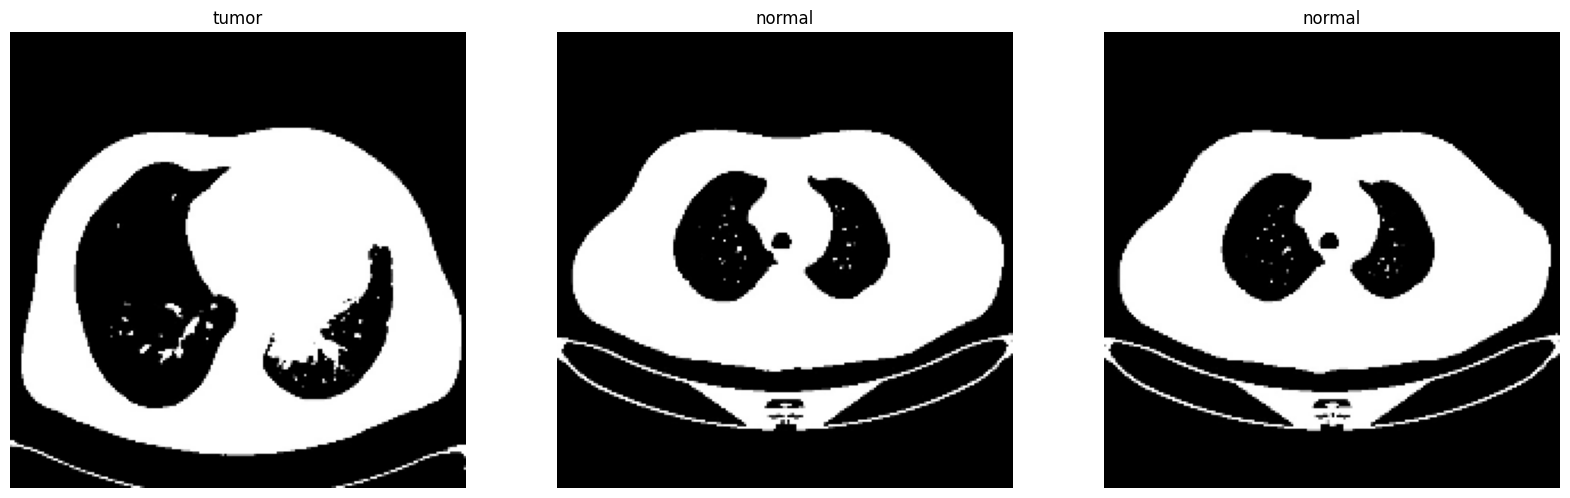

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

x = np.array(["cnn", "svm", "knn", "random forest", "decision tree"])
y = np.array([98, 98, 95, 87, 95])

plt.figure(figsize=(8, 5))  # Adjust figure size if necessary
plt.title("Model Accuracy")
plt.xlabel("Accuracy")
plt.ylabel("Model")

# Plotting horizontal bars
plt.barh(x, y, color='skyblue')

# Adding the accuracy values on the plot
for i, v in enumerate(y):
    plt.text(v + 1, i, str(v), color='black', va='center')

plt.show()


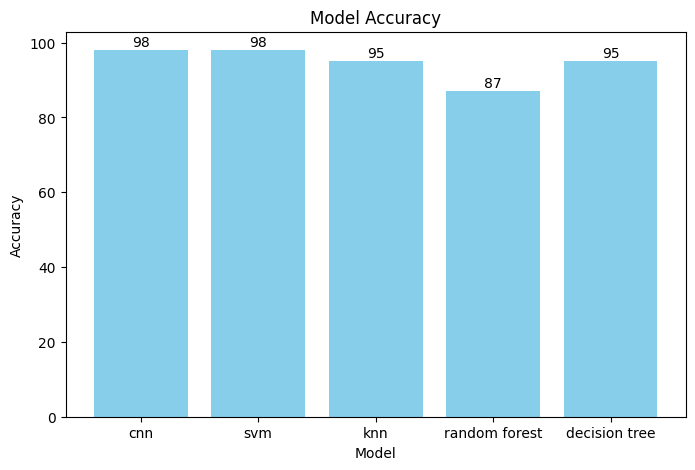

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

x = np.array(["cnn", "svm", "knn", "random forest", "decision tree"])
y = np.array([98, 98, 95, 87, 95])

plt.figure(figsize=(8, 5))  # Adjust figure size if necessary
plt.title("Model Accuracy")
plt.xlabel("Model")
plt.ylabel("Accuracy")

# Plotting vertical bars
bars = plt.bar(x, y, color='skyblue')

# Adding the accuracy values on the plot
for i, v in enumerate(y):
    plt.text(i, v + 1, str(v), color='black', ha='center')

#plt.xticks(rotation=45)  # Rotate x-axis labels by 45 degrees

plt.show()


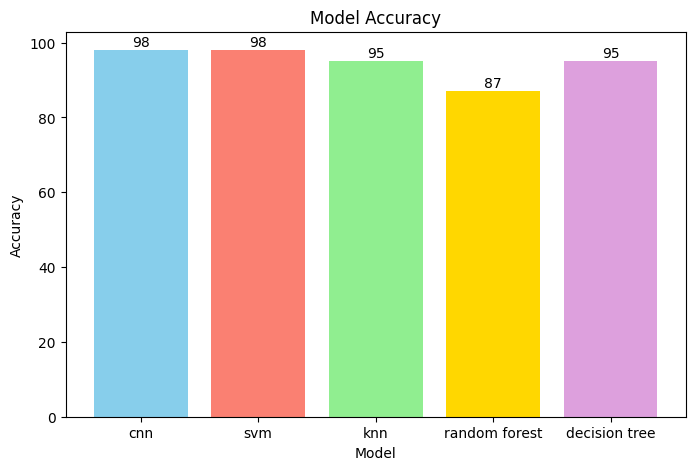

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

x = np.array(["cnn", "svm", "knn", "random forest", "decision tree"])
y = np.array([98, 98, 95, 87, 95])

plt.figure(figsize=(8, 5))  # Adjust figure size if necessary
plt.title("Model Accuracy")
plt.xlabel("Model")
plt.ylabel("Accuracy")

# Define colors for each column
colors = ['skyblue', 'salmon', 'lightgreen', 'gold', 'plum']

# Plotting vertical bars with different colors
bars = plt.bar(x, y, color=colors)

# Adding the accuracy values on the plot
for i, v in enumerate(y):
    plt.text(i, v + 1, str(v), color='black', ha='center')

#plt.xticks(rotation=45)  # Rotate x-axis labels by 45 degrees

plt.show()


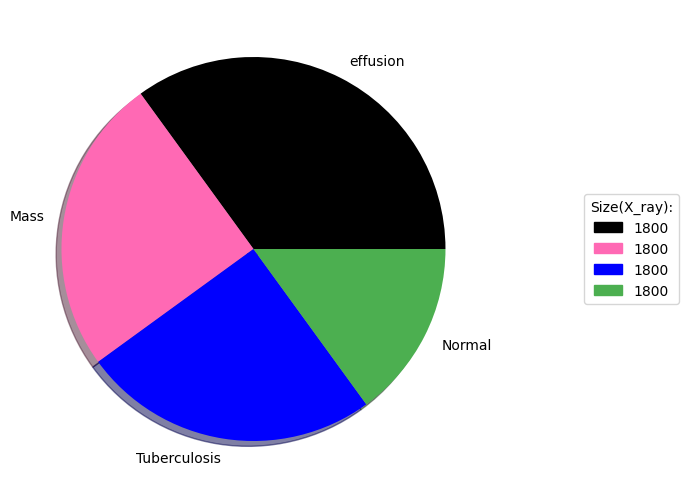

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

y = np.array([35, 25, 25, 15])
mylabels = ["effusion", "Mass", "Tuberculosis", "Normal"]
mycolors = ["black", "hotpink", "b", "#4CAF50"]
legend_labels = ["1800", "1800", "1800", "1800"]  # Different legend labels
plt.pie(y, labels=mylabels, colors=mycolors, shadow=True)

# Adjusting the position of the current Axes object to center it
plt.gca().set_position([ 1,1,1, 1])


# Create legend patches with the same colors as the pie chart
legend_patches = [mpatches.Patch(color=color, label=label) for color, label in zip(mycolors, legend_labels)]

plt.legend(handles=legend_patches,title="Size(X_ray):", loc="center right", bbox_to_anchor=(1.4, 0.5))
plt.show()


In [ ]:
KerasModel.save("model.h5")
# from keras.models import load_model
# load_model=load_model("model.h5")